# Micrograd

Description:
- Open source engine that implements backpropagation (tune weights and parameters )
- 'Heart' of neural network algorithms
- DAG applying chain rule
- Input values (ie. a, b) -> internal nodes (ie. c, d, e, f) -> output nodes (ie. g)

Sources:
- Based on https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ - full credit to Andrej Karpathy

How this fits into broader project:
- Used for neural network -> neural network builds transformer architecture -> create video-processing 

# Simple Function Derivative - One Input

In [188]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
# display as inline

In [189]:
# create scalar function
def f(x): 
    return 8 * x ** 2  + 2 * x + 3

In [190]:
f(5)

213

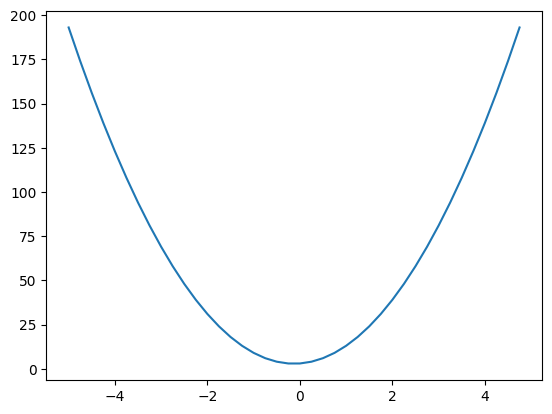

In [191]:
# input array into scalar function
xs = np.arange(-5, 5, 0.25) # generate array from -5 to 5, step 0.25
ys = f(xs)
plt.plot(xs, ys)

In [192]:
# Method: instead of deriving derivative, we 'step' towards absolute min
# Derivative: slope given small change in x

h = 0.00001
x = -0.1 # abs minimum, close to slope 0
(f(x+h) - f(x) ) / h

0.40008000001812144

# Function Derivative - Multiple Inputs

In [193]:
a = 1
b = 2
c = 3
d = a*b + c
d

5

In [194]:
h = 0.00001
a = 1

# derivative w/ respect to one variable (ie. a)
d1 = a*b + c
a += h
d2 = a*b + c

(d2 - d1) / h

2.0000000000131024

In [195]:
(f(d2) - f(d1)) / h

164.00032000092324

# Creating Value Object

# 

In [196]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10, label='c')

e = a*b; e.label='e'
d = e+c; d.label='d'

f = Value(6, label='f')
L = d*f; L.label='L'
L

Value(data=24.0)

In [197]:
# Visualizing - copied directly
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

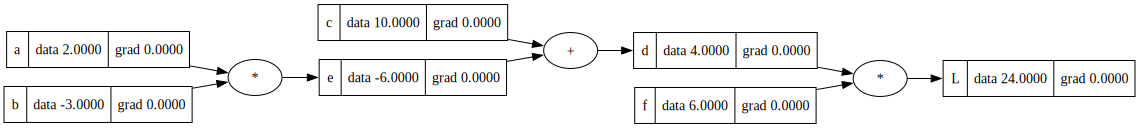

In [198]:
draw_dot(L)

# Adding Backpropagation - Manual w/ Simple Expression

In [199]:
# Example
def lol():
    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')

    e = a*b; e.label='e'
    d = e+c; d.label='d'

    f = Value(6, label='f')
    L = d*f; L.label='L'
    L1 = L.data
    
    
    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')

    e = a*b; e.label='e'
    d = e+c; d.label='d'

    f = Value(6, label='f')
    L = d*f; L.label='L'
    L2 = L.data
    
    print((L2-L1)/h)
    
lol()
    

-18.00000000006463


In [200]:
d

Value(data=4.0)

In [201]:
L.grad = 1.0
f.grad = d.data
d.grad = f.data

e.grad = d.grad
c.grad = d.grad

a.grad = e.grad * b.data
b.grad = e.grad * a.data

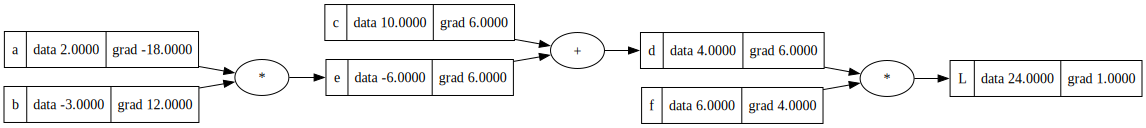

In [202]:
draw_dot(L)

In [203]:
# Optimization step
# To get L to increase, nudge lead nodes (which we have control over) in direction of grad

print(L)

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
e = a*b
d = e+c
L = d*f

print(L)

Value(data=24.0)
Value(data=29.103136000000003)


# Adding Backpropagation - Manual w/ Neuron

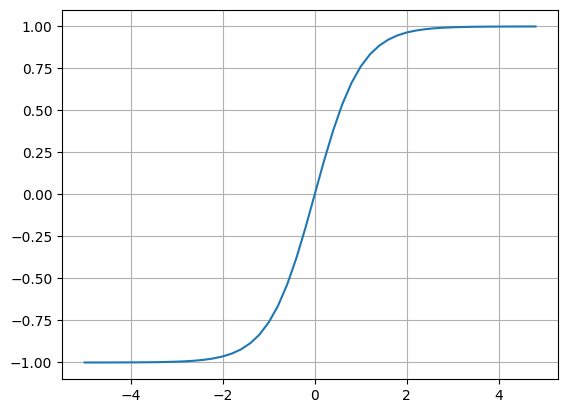

In [204]:
# "Squashing"/activation function
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [205]:
# Expanding Value object
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        out = Value((np.exp(2*self.data)-1)/(np.exp(2*self.data)+1), (self, ), 'tanh')
        return out


In [206]:
a = Value(1.0, label='a')
a.tanh()

Value(data=0.7615941559557649)

In [207]:
# Sample neuron
x1 = Value(3.0, label='x1')
x2 = Value(-2.0, label='x2')

w1 = Value(-1.0, label='w1')
w2 = Value(2.0, label='w2')

b = Value(7.88137358, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh(); o.label='o'

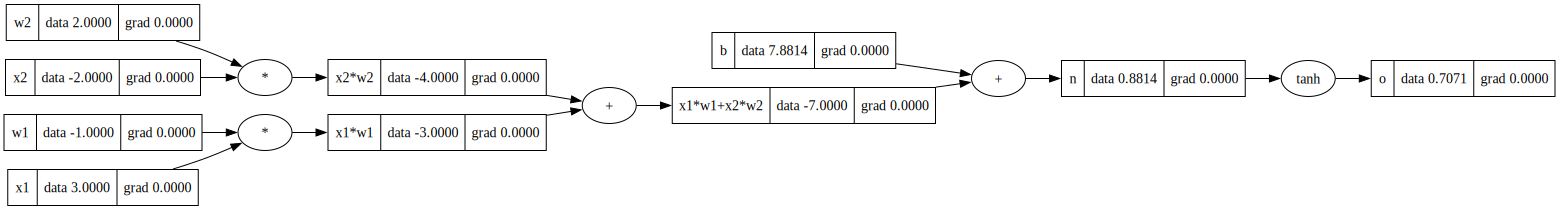

In [208]:
draw_dot(o)

In [209]:
# Assigning gradients (manually)
o.grad = 1.0
n.grad = 1 - (o.data)**2
b.grad = 1.0
b.grad = n.grad
x1w1x2w2.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad
x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data
x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data


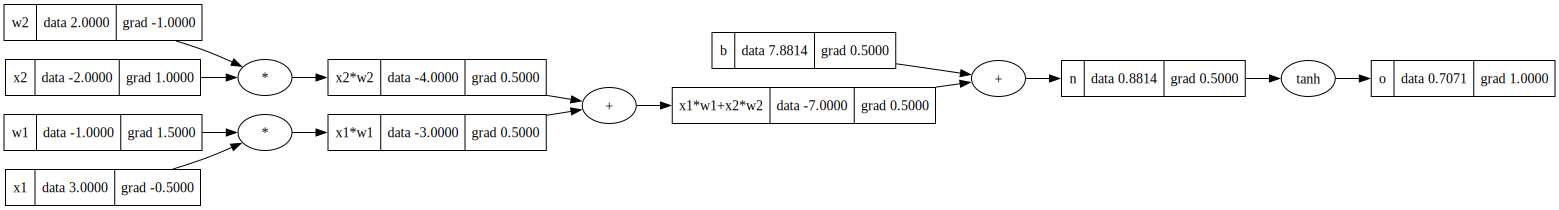

In [210]:
draw_dot(o)

In [211]:
# Generalizing backpropagation 

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # empty function
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        
        return out
    
    def tanh(self):
        t = (np.exp(2*self.data)-1)/(np.exp(2*self.data)+1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

In [212]:
# Sample neuron
x1 = Value(3.0, label='x1')
x2 = Value(-2.0, label='x2')

w1 = Value(-1.0, label='w1')
w2 = Value(2.0, label='w2')

b = Value(7.88137358, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh(); o.label='o'

In [213]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

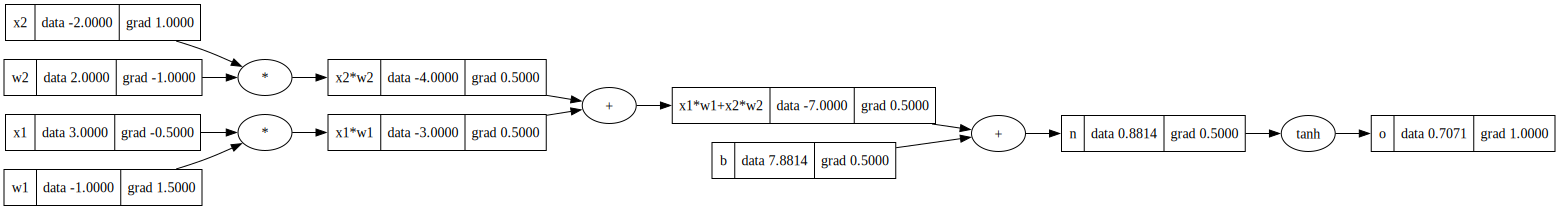

In [214]:
draw_dot(o)

In [215]:
# 'Automating' backpropagation through topological sort

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
    
for node in reversed(topo):
    node._backward()

In [216]:
# Abstracting backward functionality

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # empty function
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        
        return out
    
    def tanh(self):
        t = (np.exp(2*self.data)-1)/(np.exp(2*self.data)+1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

# Testing

In [223]:
x1 = Value(3.0, label='x1')
w1 = Value(-1.0, label='w1')

x2 = Value(2.0, label='x2')
w2 = Value(1.5, label='w2')

#x3 = Value(-2.0, label='x3')
#w3 = Value(0.5, label='w3')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
#x3w3 = x3*w3; x3w3.label='x3w3'

a = x1w1 + x2w2 #+ x3w3; a.label='a'
b = Value(2.0, label='b')

n = a+b; n.label='n'
o = n.tanh(); o.label='o'

o.backward()

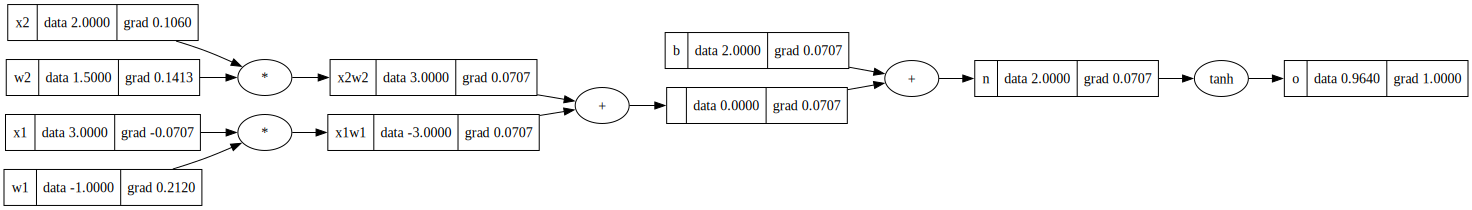

In [224]:
draw_dot(o)

# Patch - Node Used Multiple Times

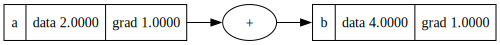

In [219]:
# If node is used multiple times, grad value wrong

#ie. 
a = Value(2.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

# a.grad should be 2.0 (b = a + a)
# same issue arises w/ d = a + b, e = a * e


In [220]:
# Final Iteration of Value

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # empty function
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def tanh(self):
        t = (np.exp(2*self.data)-1)/(np.exp(2*self.data)+1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

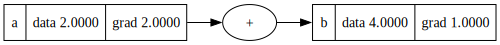

In [221]:
a = Value(2.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

# PyTorch Comparison

In [222]:
import torch
# based on tensors, not scalars

In [229]:
# cast as double for precision point, match python
x1 = torch.Tensor([3.0]).double(); x1.requires_grad = True
w1 = torch.Tensor([-1.0]).double(); w1.requires_grad = True

x2 = torch.Tensor([2.0]).double(); x2.requires_grad = True
w2 = torch.Tensor([1.5]).double(); w2.requires_grad = True

b = torch.Tensor([2.0]).double(); b.requires_grad = True

n = x1*w1+x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('Values are as follows:')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())
# pytorch efficiency comes from its use of tensors - otherwise, micrograd is similar API

0.9640275800758169
Values are as follows:
x1 -0.07065082485316443
w1 0.2119524745594933
x2 0.10597623727974664
w2 0.14130164970632886


# Building Neural Net

In [ ]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
        
        def __call__(self, x):